# Visualizing benchmark results: `benchmark_runs.csv`

This notebook loads `benchmark_runs.csv` produced by **Step 6** of `main_eval.ipynb` and summarizes **wall-clock time** for **Expected Attention** vs **KVzip**.

**How to use**: Open this notebook from the **project root** (same folder as `benchmark_runs.csv`). If the CSV lives elsewhere, set `CSV_PATH` in the first code cell below.

**Requirements**: `pandas`, `matplotlib`, `numpy` (preinstalled on Colab; locally: `pip install pandas matplotlib`).

## 1. Column reference

| Column | Meaning |
|--------|--------|
| `review` | Review text (as stored in the CSV) |
| `task` | Task prompt (filter- or extract-style question) |
| `ratio` | KV compression ratio (e.g. 0.2–0.9) |
| `ea_s` | Wall time (seconds) for one `generate` with **ExpectedAttentionPress** |
| `kvzip_s` | Wall time (seconds) for one `generate` with **KVzipPress** |
| `ea_out` / `kvzip_out` | Raw model outputs (this notebook focuses on **timing**, not automatic semantic accuracy) |

Each row = one pair of runs (EA and KVzip) for the same `(review, task, ratio)`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

ROOT = Path.cwd()
CSV_PATH = ROOT / "benchmark_runs.csv"
OUT_DIR = ROOT / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "figure.dpi": 120,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
    }
)

## 2. Load and preprocess

- Coerce timing columns to numeric and drop rows with missing values.
- Add **`kvzip_over_ea`** = `kvzip_s / ea_s`: how many times slower KVzip was than EA on that row.

In [2]:
df = pd.read_csv(CSV_PATH)
for col in ("ea_s", "kvzip_s", "ratio"):
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["ea_s", "kvzip_s", "ratio"])
df["kvzip_over_ea"] = df["kvzip_s"] / df["ea_s"]

by_ratio = (
    df.groupby("ratio", sort=True)
    .agg(
        ea_mean=("ea_s", "mean"),
        ea_std=("ea_s", "std"),
        kv_mean=("kvzip_s", "mean"),
        kv_std=("kvzip_s", "std"),
        n=("ea_s", "count"),
    )
    .reset_index()
)

ratios = by_ratio["ratio"].values
print(f"Valid rows: {len(df)}, compression ratios: {list(ratios)}")
display(by_ratio)

Valid rows: 100, compression ratios: [0.2, 0.4, 0.6, 0.8, 0.9]


,ratio,ea_mean,ea_std,kv_mean,kv_std,n
0,0.2,3.302644,0.459384,5.469436,0.313507,20
1,0.4,3.235388,0.271851,5.435857,0.282426,20
2,0.6,3.214501,0.245577,5.664301,1.107211,20
3,0.8,3.190940,0.213839,5.434617,0.247170,20
4,0.9,3.246249,0.244063,5.439752,0.295574,20


## 3. Figure 1: Mean latency by compression ratio (bar chart)

- **X-axis**: compression ratio `ratio`.
- **Y-axis**: mean wall time per `generate` (seconds), averaged over all tasks at that ratio.
- **Error bars**: ±1 standard deviation across **different tasks** (not a confidence interval over repeated runs unless you ran the same `(review, task, ratio)` multiple times).

**How to read**: A stable gap between the two bars means **KVzip is systematically slower than EA**. If heights barely move with `ratio`, **choice of method** may dominate **compression strength** in your setup.

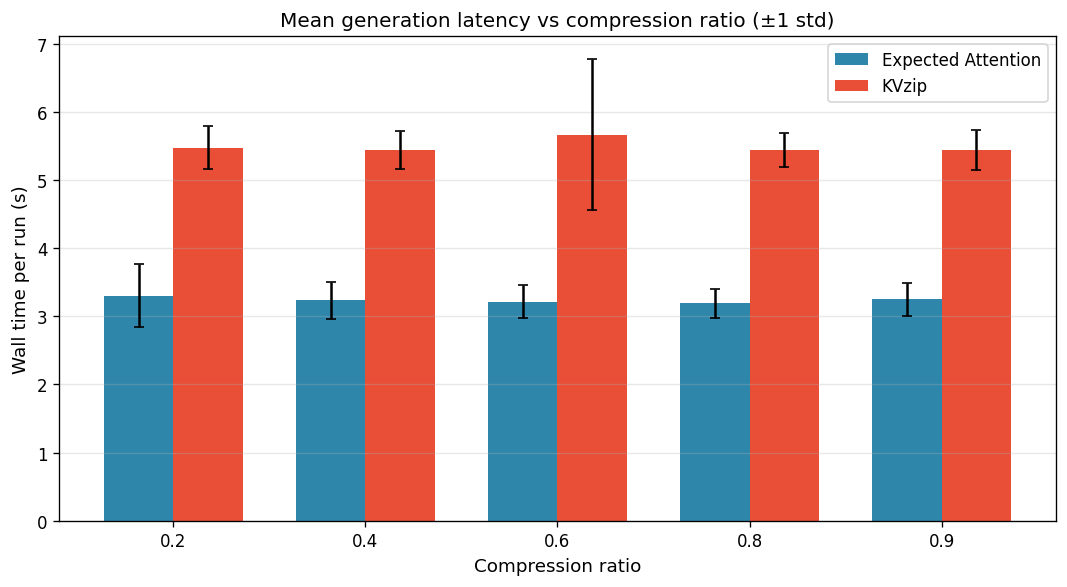

In [3]:
x = np.arange(len(ratios))
w = 0.36

fig, ax = plt.subplots()
ax.bar(
    x - w / 2,
    by_ratio["ea_mean"],
    w,
    label="Expected Attention",
    color="#2E86AB",
    yerr=by_ratio["ea_std"],
    capsize=3,
)
ax.bar(
    x + w / 2,
    by_ratio["kv_mean"],
    w,
    label="KVzip",
    color="#E94F37",
    yerr=by_ratio["kv_std"],
    capsize=3,
)
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in ratios])
ax.set_xlabel("Compression ratio")
ax.set_ylabel("Wall time per run (s)")
ax.set_title("Mean generation latency vs compression ratio (±1 std)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "latency_by_ratio_bars.png")
plt.show()

## 4. Figure 2: Mean latency vs ratio (line + band)

Same aggregated statistics as Figure 1; lines make **trends** easier to see. Shaded bands are mean ±1 standard deviation across tasks.

A very wide band for KVzip at some ratio often means **a few unusually slow runs** (e.g. a task that exercised a longer path).

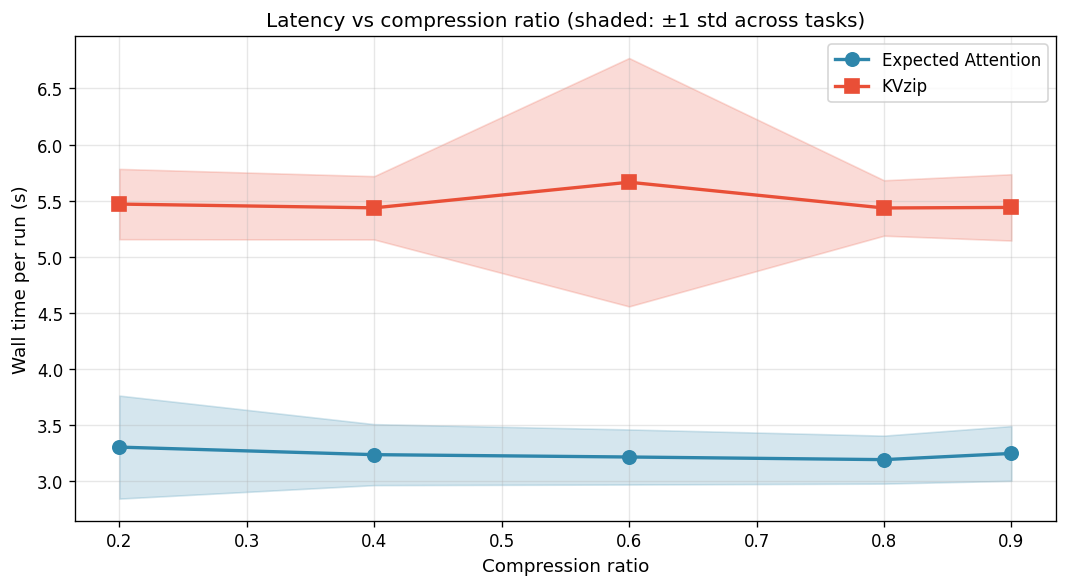

In [4]:
fig, ax = plt.subplots()
ax.plot(ratios, by_ratio["ea_mean"], "o-", color="#2E86AB", label="Expected Attention", linewidth=2, markersize=8)
ax.fill_between(
    ratios,
    by_ratio["ea_mean"] - by_ratio["ea_std"],
    by_ratio["ea_mean"] + by_ratio["ea_std"],
    color="#2E86AB",
    alpha=0.2,
)
ax.plot(ratios, by_ratio["kv_mean"], "s-", color="#E94F37", label="KVzip", linewidth=2, markersize=8)
ax.fill_between(
    ratios,
    by_ratio["kv_mean"] - by_ratio["kv_std"],
    by_ratio["kv_mean"] + by_ratio["kv_std"],
    color="#E94F37",
    alpha=0.2,
)
ax.set_xlabel("Compression ratio")
ax.set_ylabel("Wall time per run (s)")
ax.set_title("Latency vs compression ratio (shaded: ±1 std across tasks)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "latency_by_ratio_lines.png")
plt.show()

## 5. Figure 3: KVzip / EA time ratio (violin plot)

Per-row ratio **`kvzip_s / ea_s`**, grouped by `ratio`.

- **Dashed line y = 1**: both methods take the same time.
- Most mass **above 1**: KVzip is usually slower per run (consistent with extra forward passes).
- Wider spread: relative cost varies more across **tasks**.

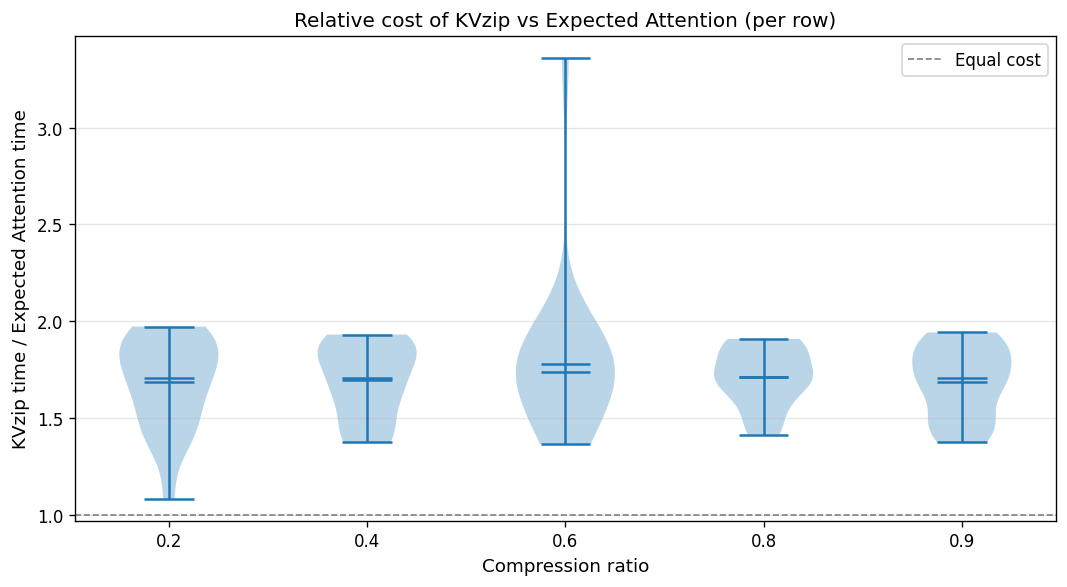

In [5]:
ratio_sorted = sorted(df["ratio"].unique())
fig, ax = plt.subplots()
ax.violinplot(
    [df.loc[df["ratio"] == r, "kvzip_over_ea"].values for r in ratio_sorted],
    positions=range(len(ratio_sorted)),
    showmeans=True,
    showmedians=True,
)
ax.set_xticks(range(len(ratio_sorted)))
ax.set_xticklabels([str(r) for r in ratio_sorted])
ax.set_xlabel("Compression ratio")
ax.set_ylabel("KVzip time / Expected Attention time")
ax.set_title("Relative cost of KVzip vs Expected Attention (per row)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Equal cost")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "kvzip_speedup_violin.png")
plt.show()

## 6. Figure 4: Scatter of EA vs KVzip per run

- **X**: EA time, **Y**: KVzip time; **diagonal** is equality.
- **Points above the diagonal**: KVzip slower.
- **Color / marker** encodes compression ratio.

Useful to show that **most points lie above the diagonal** in a report.

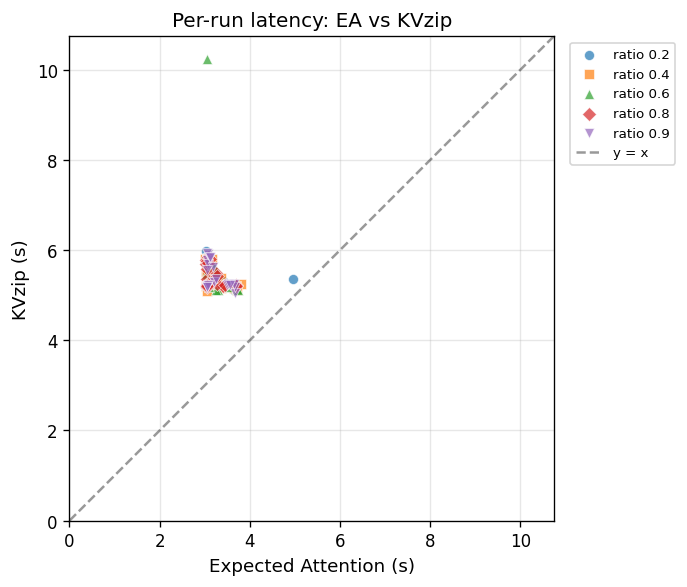

In [6]:
ratio_sorted = sorted(df["ratio"].unique())
markers = ["o", "s", "^", "D", "v"]
fig, ax = plt.subplots()
for i, r in enumerate(ratio_sorted):
    sub = df[df["ratio"] == r]
    ax.scatter(
        sub["ea_s"],
        sub["kvzip_s"],
        label=f"ratio {r}",
        alpha=0.7,
        s=36,
        marker=markers[i % len(markers)],
        edgecolors="white",
        linewidths=0.5,
    )
lim = max(df["ea_s"].max(), df["kvzip_s"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.4, label="y = x")
ax.set_xlabel("Expected Attention (s)")
ax.set_ylabel("KVzip (s)")
ax.set_title("Per-run latency: EA vs KVzip")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "scatter_ea_vs_kvzip.png", bbox_inches="tight")
plt.show()

## 7. Global summary

Prints **dataset-wide** mean times and mean **KVzip/EA** for abstracts or report text.

**Note**: This CSV has **no gold labels**, so you cannot compute accuracy from it alone; for quality evaluation, add human judgments or align with reference answers.

In [7]:
print(
    f"Overall mean: EA {df['ea_s'].mean():.3f} s | KVzip {df['kvzip_s'].mean():.3f} s | "
    f"mean KVzip/EA = {df['kvzip_over_ea'].mean():.3f}x"
)
print(f"Figures saved under: {OUT_DIR.resolve()}")

Overall mean: EA 3.238 s | KVzip 5.489 s | mean KVzip/EA = 1.711x
Figures saved under: D:\EURECOM2025\26年上半年\学期项目\kv-compression-benchmark\figures
